In [1]:
import os
os.chdir("..")
os.chdir("..")

from ducks.utils.utils import notebook_line_magic
notebook_line_magic()

Line Magic Set


In [3]:
import numpy as np

from ducks.utils.plotting_utils import plot_reward_distribution_by_episode_quantile#, plot_dist_from_sample
from ducks.utils.training_utils import (load_minari_dataset, get_filtered_episodes_from_minari_dataset, 
    get_rewards_by_episode_quantile, get_dataloader_from_episodes)


Dataset Name:  mujoco/hopper/simple-v0
Observation space: Box(-inf, inf, (11,), float64)
Action space: Box(-1.0, 1.0, (3,), float32)
Total episodes: 1952
Total steps: 999206





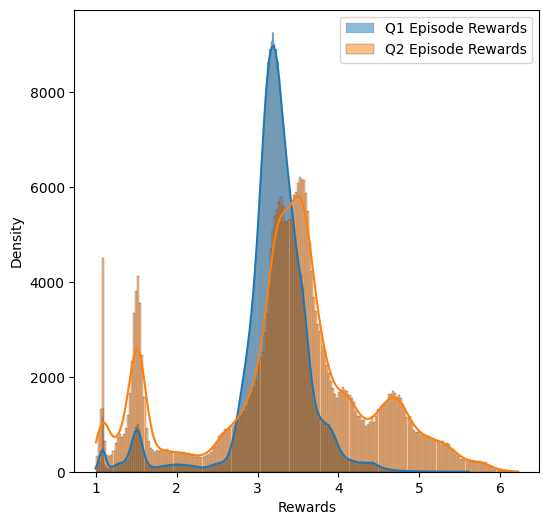

In [4]:
minari_dataset = load_minari_dataset()
filtered_episode_datasets = get_filtered_episodes_from_minari_dataset(minari_dataset) #use these filtered episodes to create dataloaders
episode_rewards_by_quantile = get_rewards_by_episode_quantile(filtered_episode_datasets)
plot_reward_distribution_by_episode_quantile(episode_rewards_by_quantile)

In [11]:
dataloaders = get_dataloader_from_episodes(filtered_episode_datasets)
sample_from_batch = next(iter(dataloaders[0]))['observations'][:1] #get one observation

In [12]:
# torch.movedim(sample_from_batch, 0, 1).shape
sample_from_batch.shape

torch.Size([1, 1024, 11])

- How to combine observations, actions, and rewards to train a diffusion model? maybe trees?

In [36]:
# each episode is made of a variable number of steps. Each step is made of a (State, Action, Reward) tuple.
# import numpy as np
# obs = []
# for ep in minari_dataset.iterate_episodes(episode_indices=[1,2,3,4,7]):
#     print(ep.rewards.shape)

# torch.as_tensor(ep.observations).unsqueeze(0).shape

In [9]:
def plot_dist_from_sample(sample):
    import seaborn as sns
    import matplotlib.pyplot as plt
    sns.displot(sample.cpu().numpy(), kind="hist", height=2, aspect=1.5)
    plt.show()

In [9]:
# for ep in filtered_episode_datasets[1].iterate_episodes(episode_indices=[4,7]):
#     print(ep.observations)

### Training Pipeline

In [13]:
import torch
from torchvision import transforms
from diffusers import DDPMScheduler
import matplotlib.pyplot as plt
import seaborn as sns
device="cuda"

T = 1000
noise_scheduler = DDPMScheduler(num_train_timesteps=T)

##add noise to a sample of 8 observations and visualize 1 out of 8
timesteps = torch.linspace(0, T-1, 8).long().to(device) #T-1 would be 999. 0-999 is 1000 steps
noise = torch.randn_like(sample_from_batch)
noisy_xb = noise_scheduler.add_noise(sample_from_batch, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)

Noisy X shape torch.Size([8, 1024, 11])


In [20]:
noisy_x.numpy().shape

(1024, 11)

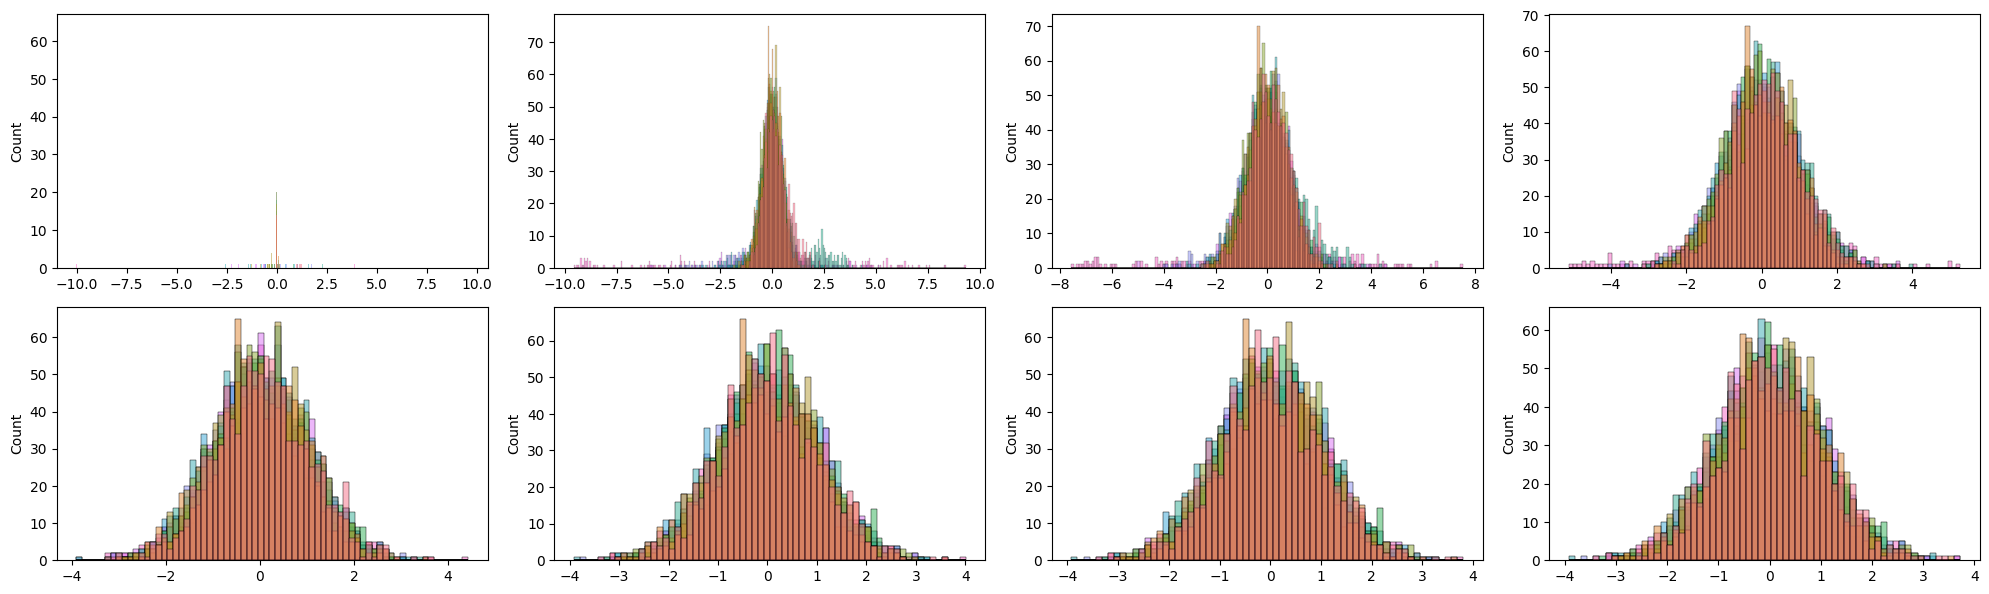

In [17]:
num_plots = 10
stepsize = int(T/num_plots)

fig, axs = plt.subplots(2, len(noisy_xb)//2, figsize=(20,6))
axs = axs.flatten()
for ax, noisy_x in zip(axs, noisy_xb):
    # plot_dist_from_sample(x)
    sns.histplot(noisy_x.numpy(), kde=False, ax=ax, legend=False)
plt.tight_layout()
plt.show()

In [74]:
# sample_from_batch.shape[-1]
# x.shape

In [21]:
from diffusers import UNet1DModel

model = UNet1DModel(
    sample_size=1024,  # the target batch size
    in_channels=11,  # the number of input channels,
    out_channels=11,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock1D",  # a regular ResNet downsampling block
        "DownBlock1D",
        "AttnDownBlock1D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock1D",
    ),
    up_block_types=(
        "AttnUpBlock1D",
        "AttnUpBlock1D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock1D",
        "UpBlock1D",  # a regular ResNet upsampling block
    ),
)
model = model.to(device)

In [22]:
# noisy_xb.shape
x = noisy_xb.permute(0, 2, 1)   # [8, 11, 1001]
t = torch.randint(0, 1024, (x.shape[0],), device=device)  # example timesteps
x.shape, t.shape

(torch.Size([8, 11, 1024]), torch.Size([8]))

In [23]:
with torch.no_grad():
    model_prediction = model(x.to(device), t).sample
model_prediction.shape

torch.Size([8, 11, 1024])

In [ ]:
import torch.nn.functional as F
#  Set the noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2"
)

# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

losses = []

for epoch in range(50):
    for step, batch in enumerate(dataloaders[0]):
        clean_samples = batch["observations"].permute(0, 2, 1).to(device)
        # Sample noise to add to the images
        noise = torch.randn(clean_samples.shape).to(clean_samples.device)
        bs = clean_samples.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (bs,), device=clean_samples.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_samples, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        # Update the model parameters with the optimizer
        optimizer.step()
        optimizer.zero_grad()

    if (epoch + 1) % 5 == 0:
        loss_last_epoch = sum(losses[-len(dataloaders[0]) :]) / len(dataloaders[0])
        print(f"Epoch:{epoch+1}, loss: {loss_last_epoch}")

/home/azm0269@auburn.edu/ducks/.venv/lib/python3.10/site-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch:5, loss: 0.9313667897994702
Epoch:10, loss: 0.7754080616510831
Epoch:15, loss: 0.6841377180356246
Epoch:20, loss: 0.6432781448731055
Epoch:25, loss: 0.6188680437894968
Epoch:30, loss: 0.6039144121683561
Epoch:35, loss: 0.5954364882065699
Epoch:40, loss: 0.5920926378323481
Epoch:45, loss: 0.5770193544717935
Epoch:50, loss: 0.5901229496185596


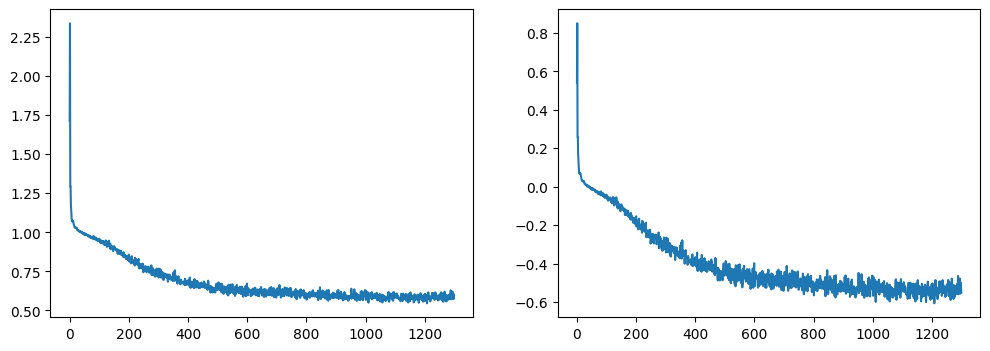

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

In [42]:
@torch.no_grad()
def sample_1d_ddpm(unet, scheduler, batch_size=1, length=None, device="cuda"):
    unet.eval()

    C = unet.config.in_channels
    L = length if length is not None else unet.config.sample_size

    # IMPORTANT: 3D noise for 1D UNet
    x = torch.randn((batch_size, C, L), device=device, dtype=torch.float32)

    scheduler.set_timesteps(scheduler.config.num_train_timesteps, device=device)

    for t in scheduler.timesteps:
        # UNet1DModel returns an object with .sample
        noise_pred = unet(x, t).sample
        step = scheduler.step(noise_pred, t, x)
        x = step.prev_sample

    return x  # [B, C, L]


L_pad = 1024  # pick a pad-safe length (32/64 multiple)
x = sample_1d_ddpm(model.to("cuda"), noise_scheduler, batch_size=1, length=L_pad)

# crop back if you need 1001
x = x[..., :1001]  # [1, C, 1001]

# if you want [B, 1, T, F] format:
x = x.permute(0, 2, 1).unsqueeze(1)  # [1, 1, 1001, 11]

In [43]:
x[0].squeeze().shape

torch.Size([1001, 11])

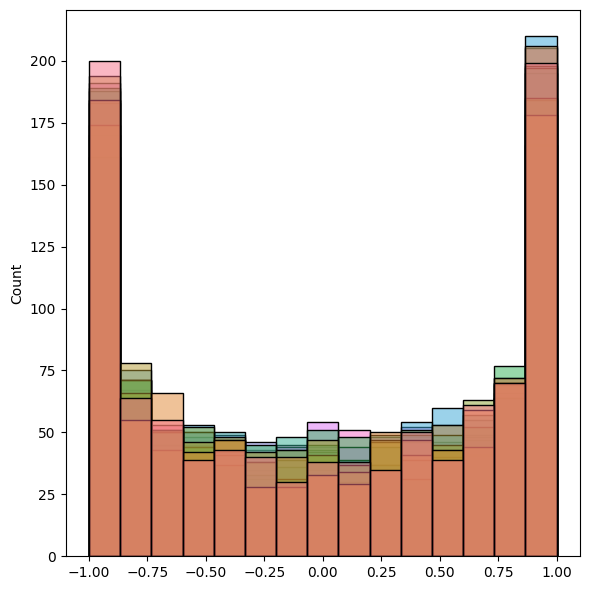

In [44]:
sns.histplot(x[0].squeeze().cpu().numpy(), kde=False, legend=False)
plt.tight_layout()
plt.show()

## Next Steps:
- Remove padding from the generated samples to get the max episode length for each episode_dataset.

1. Train a diffusion model for dataset containing episodes for each quantile
2. Interpolate the parameters for all trained models
3. Use the final interpolated model to generate new samples
4. Train an offline agent using the newly generated data
5. Iteract with each environment (based on the dataset) using the trained agent